# 静态场景 - 密度扫描实验
固定业务比例，扫描不同总密度下的性能表现

## 初始化环境

In [2]:
import sys
sys.path.insert(0, '.')

from algo.logger import reset_logger
reset_logger()

In [3]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]

# 导入评估工具（包括static_sensitivity_config和load_yaml_config）
from utils.evaluate import (
    static_sensitivity_config,
    train_and_evaluate_scenario,
    print_results_summary,
    load_yaml_config
)
import baseline
importlib.reload(baseline)
from baseline import run_episode


## 密度扫描配置生成

In [ ]:
def run_density_sweep_experiment():
    """
    密度扫描实验：固定业务比例，扫描总密度
    用于绘制：Throughput vs. Density 曲线
    """
    # 1. 定义几个固定的业务混合模式
    traffic_mixes = {
        "PBRA_Heavy": {'cbra': 0.2, 'pbra': 0.7, 'cfra': 0.1},
    }

    # 2. 定义要扫描的密度范围
    densities = [5.0, 10.0, 25.0, 40.0]
    configs = []

    print("--- Generating Density Sweep Configs ---")
    for mix_name, ratios in traffic_mixes.items():
        for d in densities:
            cfg = static_sensitivity_config(
                total_density=d,
                cbra_ratio=ratios['cbra'],
                pbra_ratio=ratios['pbra'],
                cfra_ratio=ratios['cfra']
            )
            label = f"{mix_name}_D{int(d)}"
            configs.append((label, cfg))
            print(f"Generated: [{label}]")

    return configs

# 生成配置
density_sweep_configs = run_density_sweep_experiment()
print(f"\n总共生成 {len(density_sweep_configs)} 个密度扫描场景配置")

--- Generating Density Sweep Configs ---
Generated: [PBRA_Heavy_D5]
Generated: [PBRA_Heavy_D10]
Generated: [PBRA_Heavy_D30]
Generated: [PBRA_Heavy_D50]
Generated: [PBRA_Heavy_D100]

总共生成 5 个密度扫描场景配置


## 加载训练配置

In [5]:
CONFIG_PATH = Path("conf/default.yaml")

raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)

log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_density_sweep_PBRA.log"
try:
    os.remove(log_file) if os.path.exists(log_file) else None
except Exception as e:
    print(f"Warning: Could not remove existing log file: {e}")
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized for density sweep experiment")

# 环境配置
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)

simulator_config = default_simulator_config()
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=num_slots_per_step,
    decision_horizon=80,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)

num_envs = 8
env_backend = "parallel"

train_config = HPPOConfig(
    frames_per_batch=2560,
    mini_batch_size=256,
    rollout_epochs=4,
    max_iterations=250,  # 静态场景训练100轮
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,
    entropy_coeff=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    device=torch.device(algo_section.get("device", "cpu")),
)

my_logger.info(f"Config ready | seed={seed} num_envs={num_envs}")
print(f"配置加载完成: {len(density_sweep_configs)} 个场景待训练")


2025-12-03 15:41:32 | INFO     | Logger initialized for density sweep experiment
2025-12-03 15:41:32 | INFO     | Config ready | seed=42 num_envs=8


Loaded configuration from conf\default.yaml
配置加载完成: 5 个场景待训练


## 执行密度扫描训练

In [6]:
# 全局结果存储
all_scenarios_results = OrderedDict()

print(f"\n{'='*80}")
print(f"开始批量训练 {len(density_sweep_configs)} 个密度扫描场景")
print(f"{'='*80}\n")

for idx, (label, sim_config) in enumerate(density_sweep_configs):
    print(f"\n[{idx+1}/{len(density_sweep_configs)}] 当前场景: {label}")
    try:
        result = train_and_evaluate_scenario(
            scenario_name=label,
            sim_config=sim_config,
            env_config=env_config,
            train_config=train_config,
            build_env_func=build_gym_env,
            build_modules_func=build_hppo_modules,
            train_func=train_hppo,
            run_episode_func=run_episode,
            logger=my_logger,
            num_envs=num_envs,
            env_backend=env_backend,
            num_episodes=20,
            seed=seed
        )
        all_scenarios_results[label] = result
    except Exception as e:
        print(f"场景 {label} 训练失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景训练完成!")
print(f"成功训练场景数: {len(all_scenarios_results)}/{len(density_sweep_configs)}")
print(f"{'='*80}")

# 显示结果摘要
print_results_summary(all_scenarios_results)


开始批量训练 5 个密度扫描场景


[1/5] 当前场景: PBRA_Heavy_D5

开始训练场景: PBRA_Heavy_D5
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.2_P0.7_F0.1', cbra_density=1.0, pbra_density=3.5, cfra_density=0.5),), segments=(RegionSegment(region_name='static_D5.0_C0.2_P0.7_F0.1', length=11.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-03 15:41:32,494 [torchrl][INFO]    The info_dict_reader does not have specs. The on

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-03 15:41:38 | INFO     | Starting PPO training for scenario: PBRA_Heavy_D5


  iter=0000, reward=0.1109
  iter=0010, reward=0.3968
  iter=0020, reward=0.6084
  iter=0030, reward=0.7202
  iter=0040, reward=0.9470
  iter=0050, reward=0.9897
  iter=0060, reward=1.0947
  iter=0070, reward=1.1640
  iter=0080, reward=1.2257
  iter=0090, reward=1.3414
  iter=0100, reward=1.3252
  iter=0110, reward=1.3352
  iter=0120, reward=1.3415
  iter=0130, reward=1.3923
  iter=0140, reward=1.4124
  iter=0150, reward=1.4174
  iter=0160, reward=1.4385
  iter=0170, reward=1.4797
  iter=0180, reward=1.5245
  iter=0190, reward=1.5254
  iter=0200, reward=1.5203
  iter=0210, reward=1.5537
  iter=0220, reward=1.5445
  iter=0230, reward=1.5511
  iter=0240, reward=1.5514
训练完成: 最佳奖励=1.6458 (迭代247)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.2_P0.7_F0.1', cbra_density=1.0, pbra_density=3.5, cfra_density=0.5),), segments=(RegionSegment(region_name='static_D5.0_

2025-12-03 16:12:17 | INFO     | Starting PPO training for scenario: PBRA_Heavy_D10


  iter=0000, reward=0.1168
  iter=0010, reward=0.6693
  iter=0020, reward=0.9385
  iter=0030, reward=1.1294
  iter=0040, reward=1.2878
  iter=0050, reward=1.3406
  iter=0060, reward=1.4110
  iter=0070, reward=1.4823
  iter=0080, reward=1.5377
  iter=0090, reward=1.6336
  iter=0100, reward=1.6028
  iter=0110, reward=1.6498
  iter=0120, reward=1.6931
  iter=0130, reward=1.6975
  iter=0140, reward=1.6828
  iter=0150, reward=1.7690
  iter=0160, reward=1.7815
  iter=0170, reward=1.7701
  iter=0180, reward=1.7510
  iter=0190, reward=1.8043
  iter=0200, reward=1.7942
  iter=0210, reward=1.8110
  iter=0220, reward=1.7823
  iter=0230, reward=1.8188
  iter=0240, reward=0.0959
训练完成: 最佳奖励=1.8564 (迭代236)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D10.0_C0.2_P0.7_F0.1', cbra_density=2.0, pbra_density=7.0, cfra_density=1.0),), segments=(RegionSegment(region_name='static_D10.

...

  iter=0000, reward=-0.4905
  iter=0010, reward=0.2749
  iter=0020, reward=0.4734
  iter=0030, reward=0.6162
  iter=0040, reward=0.8432
  iter=0050, reward=1.0983
  iter=0060, reward=0.6372
  iter=0070, reward=1.0255
  iter=0080, reward=1.2194
  iter=0090, reward=1.3158
  iter=0100, reward=1.5672
  iter=0110, reward=0.3336
  iter=0120, reward=1.0843
  iter=0130, reward=1.5058
  iter=0140, reward=1.6237
  iter=0150, reward=1.5400
  iter=0160, reward=1.7854
  iter=0170, reward=1.6565
  iter=0180, reward=1.8192
  iter=0190, reward=1.8580
  iter=0200, reward=-0.2667
  iter=0210, reward=-0.1697
  iter=0220, reward=0.4333
  iter=0230, reward=0.8989
  iter=0240, reward=1.3621
训练完成: 最佳奖励=1.9435 (迭代196)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D30.0_C0.2_P0.7_F0.1', cbra_density=6.0, pbra_density=21.0, cfra_density=3.0),), segments=(RegionSegment(region_name='static_

2025-12-03 16:47:49 | INFO     | Starting PPO training for scenario: PBRA_Heavy_D50


  iter=0000, reward=-0.4672
  iter=0010, reward=-0.2064
  iter=0020, reward=0.2100
  iter=0030, reward=0.3756
  iter=0040, reward=0.6403
  iter=0050, reward=0.9532
  iter=0060, reward=1.3126
  iter=0070, reward=1.3961
  iter=0080, reward=1.4906
  iter=0090, reward=1.6328
  iter=0100, reward=1.6779
  iter=0110, reward=1.5969
  iter=0120, reward=1.8009
  iter=0130, reward=1.7839
  iter=0140, reward=1.8362
  iter=0150, reward=1.8738
  iter=0160, reward=1.7343
  iter=0170, reward=1.7929
  iter=0180, reward=1.8990
  iter=0190, reward=1.8854
  iter=0200, reward=1.9252
  iter=0210, reward=1.9603
  iter=0220, reward=1.9750
  iter=0230, reward=1.9345
  iter=0240, reward=1.9936
训练完成: 最佳奖励=2.0188 (迭代216)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D50.0_C0.2_P0.7_F0.1', cbra_density=10.0, pbra_density=35.0, cfra_density=5.0),), segments=(RegionSegment(region_name='static_

2025-12-03 17:10:51 | INFO     | Starting PPO training for scenario: PBRA_Heavy_D100


  iter=0000, reward=-0.5178
  iter=0010, reward=-0.3509
  iter=0020, reward=-0.1490
  iter=0030, reward=-0.0940
  iter=0040, reward=-0.0117
  iter=0050, reward=-0.0070
  iter=0060, reward=0.0841
  iter=0070, reward=0.0870
  iter=0080, reward=0.2047
  iter=0090, reward=0.2434
  iter=0100, reward=0.4228
  iter=0110, reward=0.5747
  iter=0120, reward=0.5740
  iter=0130, reward=0.8349
  iter=0140, reward=1.0123
  iter=0150, reward=1.3619
  iter=0160, reward=0.5819
  iter=0170, reward=0.8031
  iter=0180, reward=1.1484
  iter=0190, reward=1.4178
  iter=0200, reward=1.6001
  iter=0210, reward=1.7175
  iter=0220, reward=1.6170
  iter=0230, reward=1.7325
  iter=0240, reward=1.7487
训练完成: 最佳奖励=1.8744 (迭代247)
  评估最佳模型...
  评估最后一轮模型...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D100.0_C0.2_P0.7_F0.1', cbra_density=20.0, pbra_density=70.0, cfra_density=10.0),), segments=(RegionSegment(region_name='s

## 可视化密度扫描结果

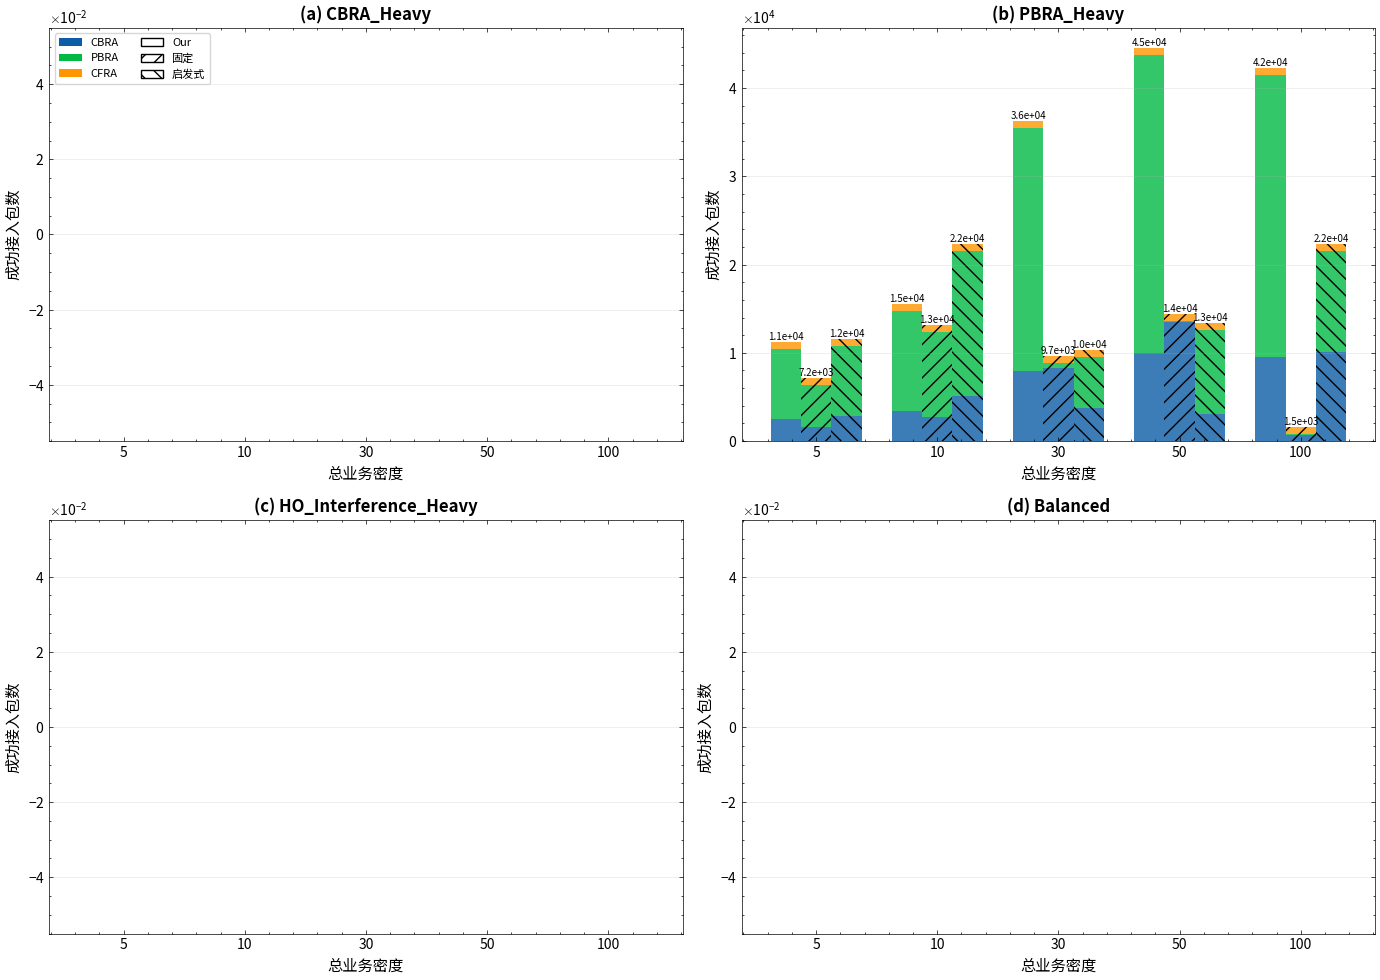

密度扫描对比图已保存到: output/static/density_sweep_comparison.svg


In [ ]:
def plot_density_sweep_results():
    """绘制密度扫描实验结果 - 单个流量模式的图"""
    traffic_mixes = ["PBRA_Heavy"]
    densities = [5.0, 10.0, 25.0, 40.0]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    for mix_idx, mix_name in enumerate(traffic_mixes):
        # 收集数据
        ppo_cbra = []
        ppo_pbra = []
        ppo_cfra = []
        ppo_theo = []
        fixed_cbra = []
        fixed_pbra = []
        fixed_cfra = []
        fixed_theo = []
        heuristic_cbra = []
        heuristic_pbra = []
        heuristic_cfra = []
        heuristic_theo = []
        total_arrivals_list = []

        for d in densities:
            label = f"{mix_name}_D{int(d)}"
            if label in all_scenarios_results:
                result = all_scenarios_results[label]

                # PPO最佳模型
                ppo_cbra.append(result['eval_results_last']['eval_success_cbra'])
                ppo_pbra.append(result['eval_results_last']['eval_success_pbra'])
                ppo_cfra.append(result['eval_results_last']['eval_success_cfra'])
                ppo_theo.append(result['eval_results_last'].get('eval_theoretical_optimal', 0))

                # 固定分配
                fixed_cbra.append(result['baseline_results']['固定分配']['success_cbra'])
                fixed_pbra.append(result['baseline_results']['固定分配']['success_pbra'])
                fixed_cfra.append(result['baseline_results']['固定分配']['success_cfra'])
                fixed_theo.append(result['baseline_results']['固定分配'].get('theoretical_optimal', 0))

                # 启发式算法
                heuristic_cbra.append(result['baseline_results']['启发式算法']['success_cbra'])
                heuristic_pbra.append(result['baseline_results']['启发式算法']['success_pbra'])
                heuristic_cfra.append(result['baseline_results']['启发式算法']['success_cfra'])
                heuristic_theo.append(result['baseline_results']['启发式算法'].get('theoretical_optimal', 0))

                # 获取总到达包数 (使用固定分配的到达数作为参考)
                total_arr = (result['baseline_results']['固定分配']['arrivals_cbra'] +
                           result['baseline_results']['固定分配']['arrivals_pbra'] +
                           result['baseline_results']['固定分配']['arrivals_cfra'])
                total_arrivals_list.append(total_arr)
            else:
                ppo_cbra.append(0)
                ppo_pbra.append(0)
                ppo_cfra.append(0)
                ppo_theo.append(0)
                fixed_cbra.append(0)
                fixed_pbra.append(0)
                fixed_cfra.append(0)
                fixed_theo.append(0)
                heuristic_cbra.append(0)
                heuristic_pbra.append(0)
                heuristic_cfra.append(0)
                heuristic_theo.append(0)
                total_arrivals_list.append(0)

        ppo_cbra = np.array(ppo_cbra)
        ppo_pbra = np.array(ppo_pbra)
        ppo_cfra = np.array(ppo_cfra)
        ppo_theo = np.array(ppo_theo)
        fixed_cbra = np.array(fixed_cbra)
        fixed_pbra = np.array(fixed_pbra)
        fixed_cfra = np.array(fixed_cfra)
        fixed_theo = np.array(fixed_theo)
        heuristic_cbra = np.array(heuristic_cbra)
        heuristic_pbra = np.array(heuristic_pbra)
        heuristic_cfra = np.array(heuristic_cfra)
        heuristic_theo = np.array(heuristic_theo)

        ppo_total = ppo_cbra + ppo_pbra + ppo_cfra
        fixed_total = fixed_cbra + fixed_pbra + fixed_cfra
        heuristic_total = heuristic_cbra + heuristic_pbra + heuristic_cfra

        # 绘制堆叠柱状图
        x = np.arange(len(densities))
        width = 0.25

        # Our (最佳) - 实心
        p1_cbra = ax.bar(x - width, ppo_cbra, width, alpha=0.8, color='C0')
        p1_pbra = ax.bar(x - width, ppo_pbra, width, bottom=ppo_cbra, alpha=0.8, color='C1')
        p1_cfra = ax.bar(x - width, ppo_cfra, width, bottom=ppo_cbra+ppo_pbra, alpha=0.8, color='C2')

        # 固定分配 - 斜线填充
        p2_cbra = ax.bar(x, fixed_cbra, width, alpha=0.8, color='C0', hatch='//')
        p2_pbra = ax.bar(x, fixed_pbra, width, bottom=fixed_cbra, alpha=0.8, color='C1', hatch='//')
        p2_cfra = ax.bar(x, fixed_cfra, width, bottom=fixed_cbra+fixed_pbra, alpha=0.8, color='C2', hatch='//')

        # 启发式算法 - 反斜线填充
        p3_cbra = ax.bar(x + width, heuristic_cbra, width, alpha=0.8, color='C0', hatch='\\\\')
        p3_pbra = ax.bar(x + width, heuristic_pbra, width, bottom=heuristic_cbra, alpha=0.8, color='C1', hatch='\\\\')
        p3_cfra = ax.bar(x + width, heuristic_cfra, width, bottom=heuristic_cbra+heuristic_pbra, alpha=0.8, color='C2', hatch='\\\\')

        # 添加理论最优值水平线 (使用平均值)
        avg_theo = np.mean([t for t in ppo_theo if t > 0])
        if avg_theo > 0:
            ax.axhline(avg_theo, color='red', linestyle='--', linewidth=2,
                      label=f'理论最优 (平均={int(avg_theo)})', zorder=10)

        # 标注总数和达最优率
        for i in range(len(densities)):
            if ppo_total[i] > 0:
                theo_rate = (ppo_total[i] / ppo_theo[i] * 100) if ppo_theo[i] > 0 else 0
                ax.text(i - width, ppo_total[i], f'{ppo_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7, color='blue')
            if fixed_total[i] > 0:
                theo_rate = (fixed_total[i] / fixed_theo[i] * 100) if fixed_theo[i] > 0 else 0
                ax.text(i, fixed_total[i], f'{fixed_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)
            if heuristic_total[i] > 0:
                theo_rate = (heuristic_total[i] / heuristic_theo[i] * 100) if heuristic_theo[i] > 0 else 0
                ax.text(i + width, heuristic_total[i], f'{heuristic_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)

        ax.set_xlabel('总业务密度 (总包数)', fontsize=12)
        ax.set_ylabel('成功接入包数', fontsize=12)
        ax.set_title(f'{mix_name} - 密度扫描性能对比', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        # 横轴标签添加总包数信息
        xticklabels = [f'{int(d)}\n({int(arr):.1e})' if arr > 0 else f'{int(d)}'
                      for d, arr in zip(densities, total_arrivals_list)]
        ax.set_xticklabels(xticklabels, fontsize=10)

        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='C0', label='CBRA'),
            Patch(facecolor='C1', label='PBRA'),
            Patch(facecolor='C2', label='CFRA'),
            Patch(facecolor='white', edgecolor='black', label='Our'),
            Patch(facecolor='white', edgecolor='black', hatch='//', label='固定'),
            Patch(facecolor='white', edgecolor='black', hatch='\\\\', label='启发式'),
        ]
        ax.legend(handles=legend_elements, fontsize=10, frameon=True, loc='upper left', ncol=2)

        ax.tick_params(labelsize=11)
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs("output/static", exist_ok=True)
    plt.savefig("output/static/density_sweep_PBRA.svg", bbox_inches='tight', dpi=300)
    plt.show()
    print("密度扫描对比图已保存到: output/static/density_sweep_PBRA.svg")

# 绘制结果
plot_density_sweep_results()
